Device:cuda  N0=2  K=4  gamma=0.0625  q=8b
Training SNR=[0,35]dB  quant starts @ epoch 50
Decoder: ch=32  B=6  epochs=300
Loading /kaggle/input/datasets/hades1998/mulituser-dataset-mlwl-project/RIS_Channels_MU_K4.mat  split='train'  K=4 ...
  OK: 40000 samples x 4 users.
Loading /kaggle/input/datasets/hades1998/mulituser-dataset-mlwl-project/RIS_Channels_MU_K4.mat  split='val'  K=4 ...
  OK: 4000 samples x 4 users.
Loading /kaggle/input/datasets/hades1998/mulituser-dataset-mlwl-project/RIS_Channels_MU_K4.mat  split='test'  K=4 ...
  OK: 4000 samples x 4 users.
Global norm  min=-1.4087e-07  max=1.4035e-07
Params: 542,892

Training 300 epochs ...
  [Ep1] Saved /kaggle/output/mu_jdcnet_n02_k4_v2_best.pth  (2.32 MB)
Ep  1/300 Q:OFF | lr=5.00e-05 | loss=4.5550e-02 | val=0.700dB [U1:1.03  U2:1.48  U3:0.82  U4:-0.54] | best=0.700dB | 82.6s
  [Ep2] Saved /kaggle/output/mu_jdcnet_n02_k4_v2_best.pth  (2.32 MB)
  [Ep3] Saved /kaggle/output/mu_jdcnet_n02_k4_v2_best.pth  (2.32 MB)
  [Ep4] Saved /ka

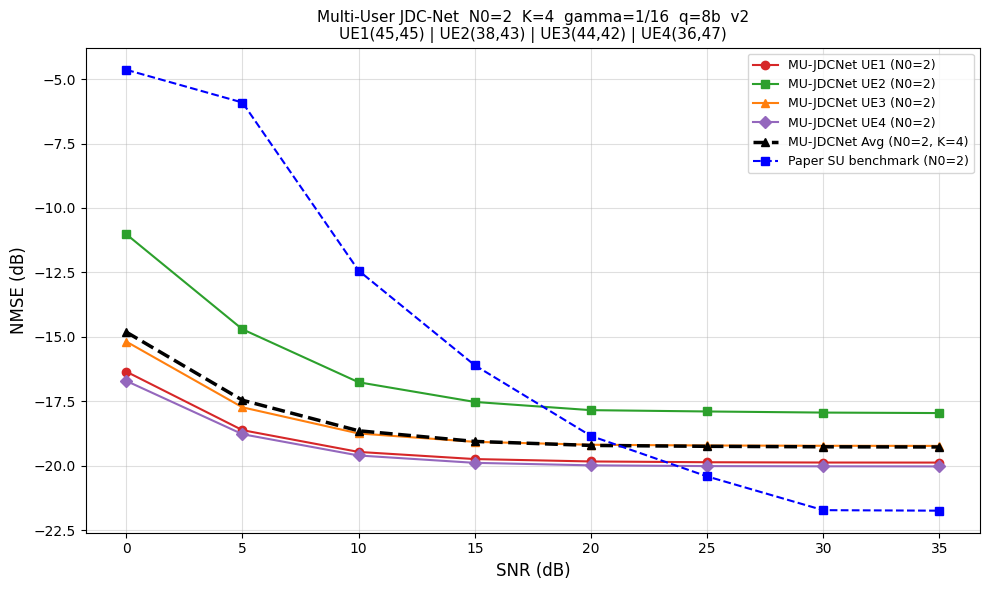


=== Final Test NMSE (dB) ===
SNR  | UE1    UE2    UE3    UE4   | Avg
---------------------------------------
  0  | -16.35  -11.02  -15.18  -16.71 | -14.81
  5  | -18.62  -14.70  -17.73  -18.77 | -17.46
 10  | -19.46  -16.76  -18.74  -19.60 | -18.64
 15  | -19.74  -17.52  -19.07  -19.88 | -19.05
 20  | -19.83  -17.84  -19.18  -19.98 | -19.21
 25  | -19.86  -17.89  -19.21  -20.01 | -19.24
 30  | -19.87  -17.94  -19.22  -20.02 | -19.26
 35  | -19.87  -17.95  -19.23  -20.02 | -19.27


In [1]:
# ================================================================
# Multi-User JDC-Net  |  N0 = 2  |  K = 4 users  |  v2 (improved)
# Dataset: RIS_Channels_MU_K4.mat  (MATLAB v7.3 HDF5, SimRIS_v18)
#
# Improvements over v1:
#   1. Training SNR range widened to [0, 35] dB (matches test range)
#   2. Quantization annealing: disabled for first 50 epochs, then ON
#   3. Larger decoder: decoder_ch=32, B=6 ResBlocks
#   4. More epochs: 300
#   5. Gradient clipping (max_norm=1.0) for stable training
#   6. Per-user NMSE tracked during training for better debugging
# ================================================================

import os, random, math, time, shutil
import numpy as np
import h5py
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

seed = 42
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False


# ================================================================
# Flexible state-dict loader
# ================================================================
def load_state_dict_flexible(path, model, map_location=None, verbose=True):
    if map_location is None:
        map_location = 'cuda' if torch.cuda.is_available() else 'cpu'
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and not all(isinstance(v, torch.Tensor) for v in sd.values()):
        if   'model_state_dict' in sd: sd = sd['model_state_dict']
        elif 'state_dict'       in sd: sd = sd['state_dict']
    sd_keys = list(sd.keys())
    if not sd_keys: raise RuntimeError('Empty state_dict')
    shm = sd_keys[0].startswith('module.')
    idp = isinstance(model, nn.DataParallel)
    if shm and not idp:  sd = {k[7:]: v for k, v in sd.items()}
    elif (not shm) and idp: sd = {'module.' + k: v for k, v in sd.items()}
    model.load_state_dict(sd)
    if verbose: print(f'[loader] Loaded from {path}')


# ================================================================
# STE Quantizer
# ================================================================
class QuantizeSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, q_bits):
        L = 2**q_bits - 1
        return torch.round(torch.clamp(x, 0., 1.) * L) / L
    @staticmethod
    def backward(ctx, g): return g, None


# ================================================================
# ResBlock
# ================================================================
class PaperResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.c1 = nn.Conv2d(ch, ch, 3, 1, 1)
        self.c2 = nn.Conv2d(ch, ch, 3, 1, 1)
        self.bn1 = nn.BatchNorm2d(ch)
        self.bn2 = nn.BatchNorm2d(ch)
        self.R  = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.R(self.bn2(self.c2(self.R(self.bn1(self.c1(x))))) + x)


# ================================================================
# Per-user decoder  (larger: decoder_ch=32, B=6)
# ================================================================
class _UserDecoder(nn.Module):
    def __init__(self, C, dch, B, N0):
        super().__init__()
        self.tc1 = nn.ConvTranspose2d(C,   dch, 4, 2, 1)
        self.tc2 = nn.ConvTranspose2d(dch, dch, 4, 2, 1)
        self.res = nn.Sequential(*[PaperResBlock(dch) for _ in range(B)])
        self.ftc = nn.ConvTranspose2d(dch, dch,
                                       kernel_size=(1, 2*N0),
                                       stride=(1, N0),
                                       padding=(0, N0//2))
        self.fc  = nn.Conv2d(dch, 2, 3, 1, 1)
    def forward(self, z):
        y = torch.relu(self.tc1(z))
        y = torch.relu(self.tc2(y))
        y = self.res(y)
        y = torch.relu(self.ftc(y))
        return self.fc(y)


# ================================================================
# Multi-User JDC-Net
# ================================================================
class MU_JDCNet(nn.Module):
    """
    Shared encoder -> SUM aggregation -> quantised bottleneck
    K parallel decoders (one per user)

    quant_enabled is toggled externally (annealing strategy).
    """
    def __init__(self, M=16, N=64, N0=2, K=4,
                 gamma=1/16, q_bits=8, B=6, decoder_ch=32,
                 quant_enabled=False):
        super().__init__()
        self.K, self.N0, self.q_bits = K, N0, q_bits
        self.quant_enabled = quant_enabled
        self.C = int(gamma * 32 * N0)
        self.encoder = nn.Sequential(
            nn.Conv2d(2,   32,    4, 2, 1), nn.ReLU(inplace=True),
            nn.Conv2d(32, self.C, 4, 2, 1)
        )
        self.decoders = nn.ModuleList(
            [_UserDecoder(self.C, decoder_ch, B, N0) for _ in range(K)]
        )

    def _bottleneck(self, lst):
        z = None
        for k in range(self.K):
            zk = self.encoder(lst[k])
            z  = zk if z is None else z + zk
        zs  = z.shape
        v   = z.view(zs[0], -1)
        vmn = v.min(1, keepdim=True)[0]
        vmx = v.max(1, keepdim=True)[0]
        den = (vmx - vmn).clamp_min(1e-12)
        if self.quant_enabled:
            vn  = (v - vmn) / den
            vq  = QuantizeSTE.apply(vn, self.q_bits)
            v   = vq * den + vmn
        return v.view(*zs)

    def forward(self, lst):
        z = self._bottleneck(lst)
        return [self.decoders[k](z) for k in range(self.K)]


# ================================================================
# h5py helper for MATLAB v7.3 complex arrays
#
# MATLAB v7.3 = HDF5. Arrays stored in Fortran (col-major) order,
# so h5py reverses all dimensions:
#   MATLAB H  (64,16,S) -> h5py (S,16,64)
#   MATLAB G_k(1,64,S)  -> h5py (S,64,1)
# ================================================================
def _load_cplx(f, key):
    ds = f[key]
    if ds.dtype.names is not None and 'real' in ds.dtype.names:
        arr = ds['real'][()] + 1j * ds['imag'][()]
    else:
        arr = ds[()]
    return arr.astype(np.complex64)


# ================================================================
# Multi-User Dataset
# ================================================================
class MURISChannelDataset(Dataset):
    """
    H  (64,16,S) -> h5py (S,16,64) -> .T(0,2,1) -> (S,64,16)
    G_k(1,64,S)  -> h5py (S,64,1)  -> .T(0,2,1) -> (S,1,64)
    Cascaded: Hc_k = G_k.T(0,2,1) * H_s  -> (S,64,16)
    Final: (S,2,16,64) float32  [real/imag, Tx, RIS]
    """
    def __init__(self, mat_file, split='train', K=4):
        print(f"Loading {mat_file}  split='{split}'  K={K} ...")
        G_keys = [f'G_{k+1}' for k in range(K)]
        sl = {'train': slice(0,40000),
              'val':   slice(40000,44000),
              'test':  slice(44000,48000)}[split]

        with h5py.File(mat_file, 'r') as f:
            missing = [key for key in ['H'] + G_keys if key not in f]
            if missing:
                raise KeyError(f"Missing keys {missing}. Available: {list(f.keys())}")

            H_raw = _load_cplx(f, 'H')        # (S,16,64)
            H_mat = H_raw.transpose(0, 2, 1)  # (S,64,16)
            H_s   = H_mat[sl]

            self.user_data = []
            for key in G_keys:
                G_raw = _load_cplx(f, key)              # (S,64,1)
                G_k   = G_raw.transpose(0, 2, 1)[sl]    # (split,1,64)
                Hc_k  = G_k.transpose(0, 2, 1) * H_s   # (split,64,16)
                real  = np.real(Hc_k).astype(np.float32)
                imag  = np.imag(Hc_k).astype(np.float32)
                stk   = np.stack([real, imag], axis=1).transpose(0, 1, 3, 2)  # (split,2,16,64)
                self.user_data.append(torch.tensor(stk, dtype=torch.float32))

        self.K = K
        print(f"  OK: {len(self.user_data[0])} samples x {K} users.")

    def __len__(self):  return len(self.user_data[0])
    def __getitem__(self, i): return tuple(self.user_data[k][i] for k in range(self.K))


# ================================================================
# LS pilot generator
# ================================================================
def generate_ls_physical(H_phys, N0, snr_db):
    """H_phys (B,2,M,N) -> noisy grouped LS estimate (B,2,M,Np)"""
    b, c, m, n = H_phys.shape
    assert n % N0 == 0
    Hg  = H_phys.view(b, c, m, n//N0, N0).mean(-1)
    pwr = torch.mean(Hg[:,0]**2 + Hg[:,1]**2, dim=[1,2])
    std = torch.sqrt(pwr / (10.0**(snr_db/10.0) * 2.0)).view(b,1,1,1)
    return Hg + torch.randn_like(Hg) * std


# ================================================================
# LR schedule: warm-up + cosine decay
# ================================================================
def lr_for_epoch(epoch, T=300, Tw=30, eta_max=2e-3, eta_min=5e-5):
    if epoch < Tw:
        return eta_min + (eta_max - eta_min) * epoch / max(1, Tw)
    t = (epoch - Tw) / max(1, T - Tw)
    return eta_min + 0.5*(eta_max - eta_min)*(1 + math.cos(math.pi*t))


def fwd(model, lst):
    if isinstance(model, nn.DataParallel): return model.module.forward(lst)
    return model(lst)


# ================================================================
# Training + evaluation pipeline
# ================================================================
def run_mu_pipeline(
    mat_path    = '/kaggle/input/YOUR_DATASET/RIS_Channels_MU_K4.mat',
    N0          = 2,
    K           = 4,
    gamma       = 1/16,
    q_bits      = 8,
    batch_size  = 256,
    epochs      = 300,
    Tw          = 30,
    eta_max     = 2e-3,
    eta_min     = 5e-5,
    quant_start = 50,    # epoch at which quantisation is switched ON
    decoder_ch  = 32,    # wider decoder
    B           = 6,     # more ResBlocks
    snr_lo      = 0,     # training SNR range (MUST cover test range)
    snr_hi      = 35,
    device      = None
):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device:{device}  N0={N0}  K={K}  gamma={gamma:.4f}  q={q_bits}b")
    print(f"Training SNR=[{snr_lo},{snr_hi}]dB  quant starts @ epoch {quant_start}")
    print(f"Decoder: ch={decoder_ch}  B={B}  epochs={epochs}")

    # ---- datasets ----
    train_ds = MURISChannelDataset(mat_path, 'train', K=K)
    val_ds   = MURISChannelDataset(mat_path, 'val',   K=K)
    test_ds  = MURISChannelDataset(mat_path, 'test',  K=K)

    # Global min/max normalisation across all users' train data
    all_tr = torch.cat([train_ds.user_data[k] for k in range(K)], 0)
    tr_min = float(all_tr.min());  tr_max = float(all_tr.max())
    del all_tr
    print(f"Global norm  min={tr_min:.4e}  max={tr_max:.4e}")

    norm   = lambda x: (x - tr_min) / (tr_max - tr_min + 1e-12)
    denorm = lambda x:  x * (tr_max - tr_min) + tr_min

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
    val_dl   = DataLoader(val_ds,   batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)
    test_dl  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)

    # ---- model (quant OFF initially) ----
    model = MU_JDCNet(M=16, N=64, N0=N0, K=K, gamma=gamma,
                      q_bits=q_bits, B=B, decoder_ch=decoder_ch,
                      quant_enabled=False)
    if torch.cuda.device_count() > 1: model = nn.DataParallel(model)
    model.to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Params: {n_params:,}")

    optimizer = optim.Adam(model.parameters())
    criterion = nn.MSELoss()

    best_nmse = 1e9
    best_path = '/kaggle/working/mu_jdcnet_n02_k4_v2_best.pth'
    out_path  = '/kaggle/output/mu_jdcnet_n02_k4_v2_best.pth'

    print(f"\nTraining {epochs} epochs ...")
    for epoch in range(epochs):

        # ---- quantisation annealing ----
        q_on = (epoch >= quant_start)
        m_inner = model.module if isinstance(model, nn.DataParallel) else model
        m_inner.quant_enabled = q_on

        model.train()
        lr = lr_for_epoch(epoch, T=epochs, Tw=Tw, eta_max=eta_max, eta_min=eta_min)
        for g in optimizer.param_groups: g['lr'] = lr

        tr_loss = 0.;  t0 = time.time()
        for btup in train_dl:
            # FIX: train across full test SNR range [snr_lo, snr_hi]
            snr = random.uniform(snr_lo, snr_hi)
            ls  = [norm(generate_ls_physical(btup[k].to(device), N0, snr)) for k in range(K)]
            gt  = [norm(btup[k].to(device)) for k in range(K)]
            optimizer.zero_grad()
            out  = fwd(model, ls)
            loss = sum(criterion(out[k], gt[k]) for k in range(K)) / K
            loss.backward()
            # FIX: gradient clipping for training stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            tr_loss += loss.item() * btup[0].size(0)
        tr_loss /= len(train_dl.dataset)
        t1 = time.time()

        # ---- validation @ 15 dB ----
        model.eval()
        vm=[0.]*K;  vp=[0.]*K
        with torch.no_grad():
            for vtup in val_dl:
                ls = [norm(generate_ls_physical(vtup[k].to(device), N0, 15.)) for k in range(K)]
                Hp = [vtup[k].to(device) for k in range(K)]
                out = fwd(model, ls)
                for k in range(K):
                    op     = denorm(out[k].cpu())
                    vm[k] += torch.sum((op.to(device) - Hp[k])**2).item()
                    vp[k] += torch.sum(Hp[k]**2).item()
        nk  = [10.*math.log10(vm[k]/(vp[k]+1e-12)) for k in range(K)]
        nav = sum(nk)/K

        if nav < best_nmse:
            best_nmse = nav
            st = model.module.state_dict() if isinstance(model,nn.DataParallel) else model.state_dict()
            torch.save(st, best_path)
            try:
                os.makedirs('/kaggle/output', exist_ok=True)
                shutil.copy(best_path, out_path)
                print(f"  [Ep{epoch+1}] Saved {out_path}  ({os.path.getsize(out_path)/1e6:.2f} MB)")
            except Exception as e:
                print(f"  Checkpoint warning: {e}")

        if (epoch+1)%10==0 or epoch==0:
            q_str = 'Q:ON ' if q_on else 'Q:OFF'
            u = '  '.join([f'U{k+1}:{nk[k]:.2f}' for k in range(K)])
            print(f"Ep{epoch+1:3d}/{epochs} {q_str} | lr={lr:.2e} | "
                  f"loss={tr_loss:.4e} | val={nav:.3f}dB [{u}] | "
                  f"best={best_nmse:.3f}dB | {t1-t0:.1f}s")

    # ================================================================
    # Test over SNR grid
    # ================================================================
    load_state_dict_flexible(best_path, model, verbose=True)
    m_inner = model.module if isinstance(model, nn.DataParallel) else model
    m_inner.quant_enabled = True   # always ON at test time
    model.eval()

    snrs=[0,5,10,15,20,25,30,35]
    res_k=[[] for _ in range(K)];  res_avg=[]

    with torch.no_grad():
        for snr in snrs:
            tm=[0.]*K;  tp=[0.]*K
            for ttup in test_dl:
                ls = [norm(generate_ls_physical(ttup[k].to(device), N0, snr)) for k in range(K)]
                Hp = [ttup[k].to(device) for k in range(K)]
                out = fwd(model, ls)
                for k in range(K):
                    op     = denorm(out[k].cpu())
                    tm[k] += torch.sum((op.to(device) - Hp[k])**2).item()
                    tp[k] += torch.sum(Hp[k]**2).item()
            nd = [10.*math.log10(tm[k]/(tp[k]+1e-12)) for k in range(K)]
            av = sum(nd)/K
            for k in range(K): res_k[k].append(nd[k])
            res_avg.append(av)
            u = '  '.join([f'U{k+1}:{nd[k]:.2f}' for k in range(K)])
            print(f"SNR {snr:2d} dB  avg={av:.3f} dB  [{u}]")

    # ================================================================
    # Plot
    # ================================================================
    paper_n02 = [-4.64,-5.91,-12.43,-16.10,-18.84,-20.41,-21.72,-21.74]

    colors  = ['tab:red','tab:green','tab:orange','tab:purple']
    markers = ['o','s','^','D']
    plt.figure(figsize=(10,6))
    for k in range(K):
        plt.plot(snrs, res_k[k], marker=markers[k], color=colors[k],
                 label=f'MU-JDCNet UE{k+1} (N0={N0})')
    plt.plot(snrs, res_avg, 'k--^', lw=2.5, label=f'MU-JDCNet Avg (N0={N0}, K={K})')
    plt.plot(snrs, paper_n02, 'b--s', label='Paper SU benchmark (N0=2)')
    plt.xlabel('SNR (dB)',  fontsize=12)
    plt.ylabel('NMSE (dB)', fontsize=12)
    plt.title(
        f'Multi-User JDC-Net  N0={N0}  K={K}  gamma=1/16  q={q_bits}b  v2\n'
        'UE1(45,45) | UE2(38,43) | UE3(44,42) | UE4(36,47)',
        fontsize=11)
    plt.grid(True, alpha=0.4)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('/kaggle/working/mu_n02_k4_v2.png', dpi=150)
    plt.show()

    # Print final summary table
    print('\n=== Final Test NMSE (dB) ===')
    hdr = 'SNR  | ' + '  '.join([f'UE{k+1}  ' for k in range(K)]) + f' | Avg'
    print(hdr)
    print('-'*len(hdr))
    for i, snr in enumerate(snrs):
        row = f'{snr:3d}  | ' + '  '.join([f'{res_k[k][i]:6.2f}' for k in range(K)]) + f' | {res_avg[i]:.2f}'
        print(row)

    return model, res_k, res_avg


# ================================================================
# Entry point
# ================================================================
mat_path = '/kaggle/input/datasets/hades1998/mulituser-dataset-mlwl-project/RIS_Channels_MU_K4.mat'

model, results_per_user, results_avg = run_mu_pipeline(
    mat_path    = mat_path,
    N0          = 2,
    K           = 4,
    gamma       = 1/16,
    q_bits      = 8,
    batch_size  = 256,
    epochs      = 300,
    Tw          = 30,
    eta_max     = 2e-3,
    eta_min     = 5e-5,
    quant_start = 50,   # First 50 epochs: no quantisation (learns representations first)
    decoder_ch  = 32,  
    B           = 6,    
    snr_lo      = 0,    
    snr_hi      = 35,
)
